## Árboles de decisión

In [ ]:
# Librerias 
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np
import scipy.stats
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score, accuracy_score,confusion_matrix,classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from math import sqrt
import os
from os import listdir
from datetime import datetime
import pandas as pd
from matplotlib.dates import DateFormatter
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split,cross_val_score
import seaborn as sns
import plotly.express as px
import kagglehub
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from pathlib import Path
print ("librerias ok")

librerias ok


In [ ]:
# Ruta del proyecto
ruta_proyecto = Path.cwd().parent
print(ruta_proyecto)
#Ruta donde se encuentra el dataset
ruta_raw = ruta_proyecto  / "housing-price-analysis" / "data"
print(ruta_raw)

#Dataset a utilizar descargado previamente de kaggle 
# https://www.kaggle.com/datasets/marcopale/housing?resource=download
archivo = ruta_raw / "AmesHousing.csv"
housing = pd.read_csv(archivo)

In [2]:
#Se descargo el dataset en la clase anterior
# El link se saca de lo que me dice kaggle antes
df_test = pd.read_csv("C:/Users/Josefina Urquiza/.cache/kagglehub/competitions/titanic/Test.csv")
df_train = pd.read_csv("C:/Users/Josefina Urquiza/.cache/kagglehub/competitions/titanic/Train.csv")
#Unimos los dos dataset
df_concat = pd.concat([df_train, df_test], ignore_index=True)
#Verificamos
print(f"Hay {len(df_test)} registros en test")
print(f"Hay {len(df_train)} registros en train")
print(f"Hay {len(df_concat)} registros en total")

# Objetivo del proyecto: Predecir si sobrevivieron o no
#Hacemos una copia del df para no trabajar sobre la original
df = df_concat.copy()
df.columns

Hay 418 registros en test
Hay 891 registros en train
Hay 1309 registros en total


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [4]:
# Se codifican las variable Sex como 0 ==> Male; 1 ==> Female.

df["Sex_encoded"] = df["Sex"].map({"male": 0, "female" : 1})


In [5]:
# Se seleccionan las variables predictoras mas relevantes
columnas = ['Survived', 'Pclass', 'Sex_encoded', 'Age', 'SibSp', 'Parch',]
df = df[columnas]

In [6]:
# Se eliminan las filas con valores nulos en ciertas columnas
df = df.dropna()

In [10]:
# Se spaaran las variables objetivo vs predictoras
X = df.drop(columns = "Survived")
y = df ["Survived"]

#Mostramos datos del dataset X
# print(X.columns)
print(X.head)

<bound method NDFrame.head of      Pclass  Sex_encoded   Age  SibSp  Parch
0         3            0  22.0      1      0
1         1            1  38.0      1      0
2         3            1  26.0      0      0
3         1            1  35.0      1      0
4         3            0  35.0      0      0
..      ...          ...   ...    ...    ...
885       3            1  39.0      0      5
886       2            0  27.0      0      0
887       1            1  19.0      0      0
889       1            0  26.0      0      0
890       3            0  32.0      0      0

[714 rows x 5 columns]>


In [11]:
# Creamos dataset de entrenamiento y testeo
x_train, x_test, y_train, y_test = train_test_split (X, y, test_size = 0.2, random_state = 42)

In [13]:
# Se crea y entrena el arbol de decision sin restriccion hasta que encuentre la pureza
# 01. Se setea el modelo
arbol_completo = DecisionTreeClassifier(random_state = 42)
# 02. Se entrena
arbol_completo.fit (x_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

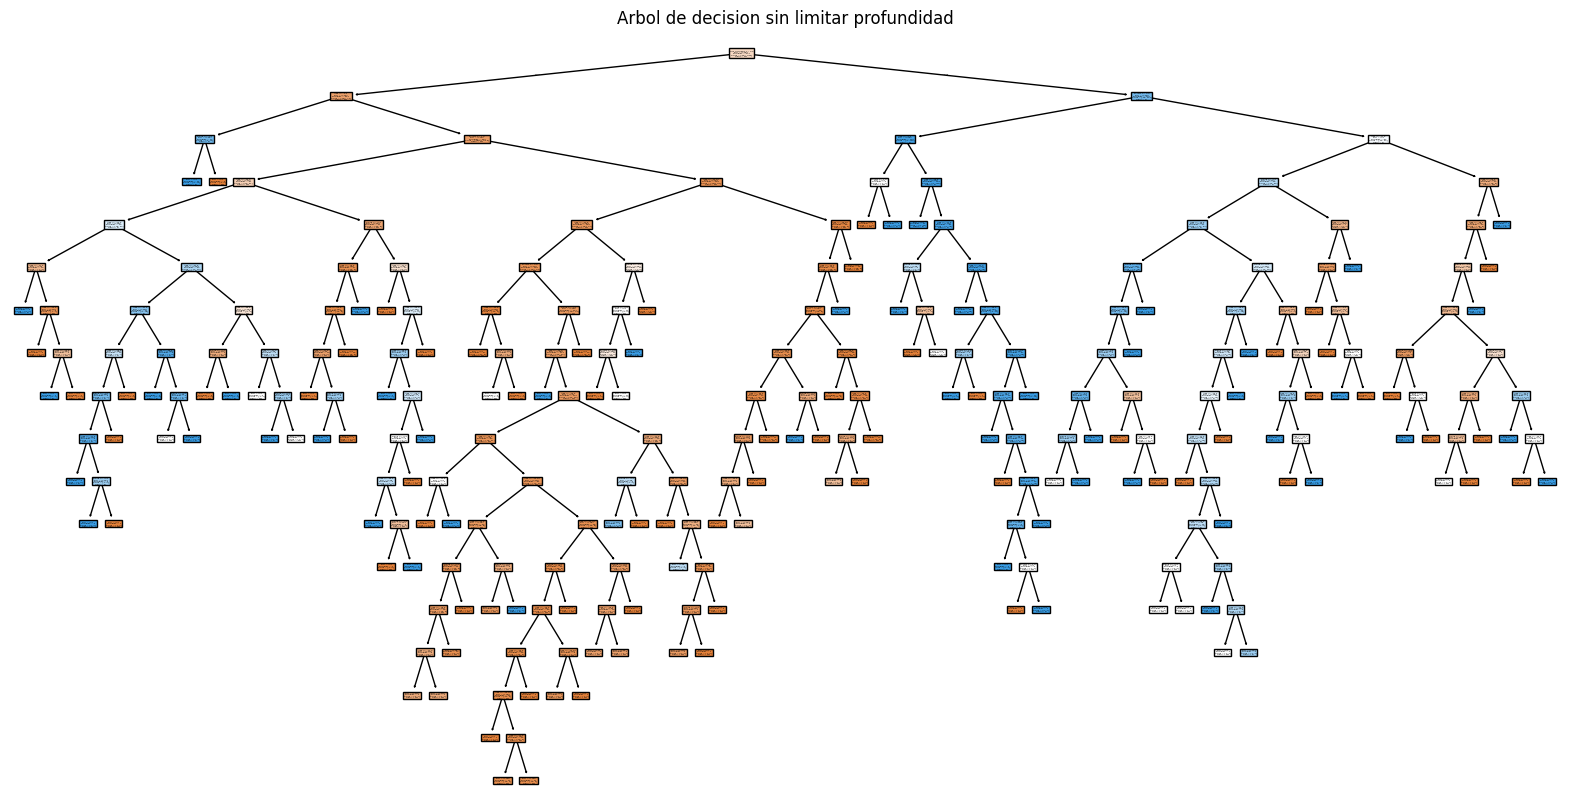

In [ ]:
# Visualizamos el arbol
plt.figure (figsize = (20,10))
plot_tree(arbol_completo, feature_names = X.columns, class_names = ["No", "Si"], filled = True)
plt.title("Arbol de decision sin limitar profundidad")
plt.show()

Da como resultado un modelo muy amplio, y desbalanceado. Seguramente da un overfitting sobre todo en lo que seria el 2do arbol.
Pero para eso hay que checkear las metricas estadisticas como rcall, accuracy

In [16]:
# Evaluacion del desempeño
# 01. Predicciones del arbol sobre el conjunto de prueba
y_pred_completo = arbol_completo.predict (x_test)

# 02. Reporte de clasificación
# \ ALT 92
print("Reporte de clasificacion -Árbol sin restricciones:\n")
print(classification_report(y_test, y_pred_completo))

# 03. Matriz de confusion
print("Matriz de confusión:")
print(confusion_matrix (y_test, y_pred_completo))


Reporte de clasificacion -Árbol sin restricciones:

              precision    recall  f1-score   support

         0.0       0.80      0.78      0.79        87
         1.0       0.67      0.70      0.68        56

    accuracy                           0.75       143
   macro avg       0.74      0.74      0.74       143
weighted avg       0.75      0.75      0.75       143

Matriz de confusión:
[[68 19]
 [17 39]]


El árbol de decisión obtuvo una accuracy del 75%, clasificando correctamente 107 de los 143 pasajeros del conjunto de prueba. El modelo presenta un mejor desempeño para identificar a los pasajeros que no sobrevivieron, con una precisión del 80% y un recall del 78%. En cambio, para la clase "Sobrevivió", la precisión fue del 67% y el recall del 70%, lo que indica que el modelo tiene más dificultades para identificar correctamente a los sobrevivientes y genera un mayor número de errores en esa clase.

Matriz de confusión:


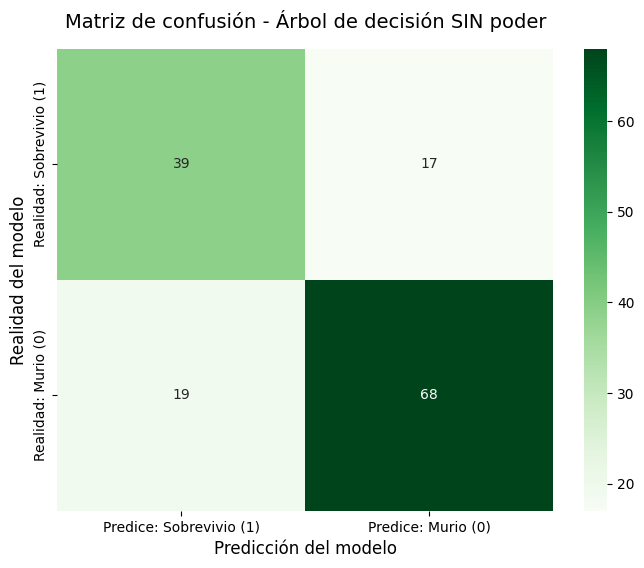

In [ ]:
# 03. Matriz de confusion, pero le cambiamos el orden para que los VP queden arriba a la izquierda
print("Matriz de confusión:")
cm_completo = confusion_matrix (y_test, y_pred_completo, labels = [1,0])

# 04. VIsualizacion
plt.figure (figsize = (8,6))
sns.heatmap (cm_completo, cmap = "Greens", annot = True, fmt = "d",
             xticklabels = ["Predice: Sobrevivió (1)", "Predice: Murió (0)"],
             yticklabels = ["Realidad: Sobrevivió (1)", "Realidad: Murió (0)"]
             )
plt.title ("Matriz de confusión - Árbol de decisión SIN poder", fontsize = 14, pad = 15)
plt.xlabel ("Predicción del modelo", fontsize = 12)
plt.ylabel ("Realidad del modelo", fontsize = 12)
plt.show()

Ahora quiero mejorar el modelo
Algunas ideas:
- Ponerle mas peso a una variable que a otra, prestarle mas atencion. Esto cambiar el recall. Esto va a castigar o penalizar. Se hace class_weight = "balanced" cuando se contruye el modelo
- Ingeniería de caracaterísticas (features)
- Hiperpáramentros

In [21]:
# Caso de balancear las variables con *class_weight = "balanced"*
# 01. Se setea el modelo
arbol_completo_balanced = DecisionTreeClassifier(random_state = 42, class_weight = "balanced")
# 02. Se entrena
arbol_completo_balanced.fit (x_train, y_train)
# Evaluacion del desempeño
# 01. Predicciones del arbol sobre el conjunto de prueba
y_pred_completo_balanced = arbol_completo_balanced.predict (x_test)

# 02. Reporte de clasificación
# \ ALT 92
print("Reporte de clasificacion - Caracteristicas balanceadas:\n")
print(classification_report(y_test, y_pred_completo_balanced))

# 03. Matriz de confusion
print("Matriz de confusión:")
print(confusion_matrix (y_test, y_pred_completo_balanced))

Reporte de clasificacion - Caracteristicas balanceadas:

              precision    recall  f1-score   support

         0.0       0.78      0.75      0.76        87
         1.0       0.63      0.68      0.66        56

    accuracy                           0.72       143
   macro avg       0.71      0.71      0.71       143
weighted avg       0.72      0.72      0.72       143

Matriz de confusión:
[[65 22]
 [18 38]]


Reporte de clasificacion - Árbol podado:

              precision    recall  f1-score   support

         0.0       0.77      0.83      0.80        87
         1.0       0.69      0.61      0.65        56

    accuracy                           0.74       143
   macro avg       0.73      0.72      0.72       143
weighted avg       0.74      0.74      0.74       143

Matriz de confusión:
[[72 15]
 [22 34]]


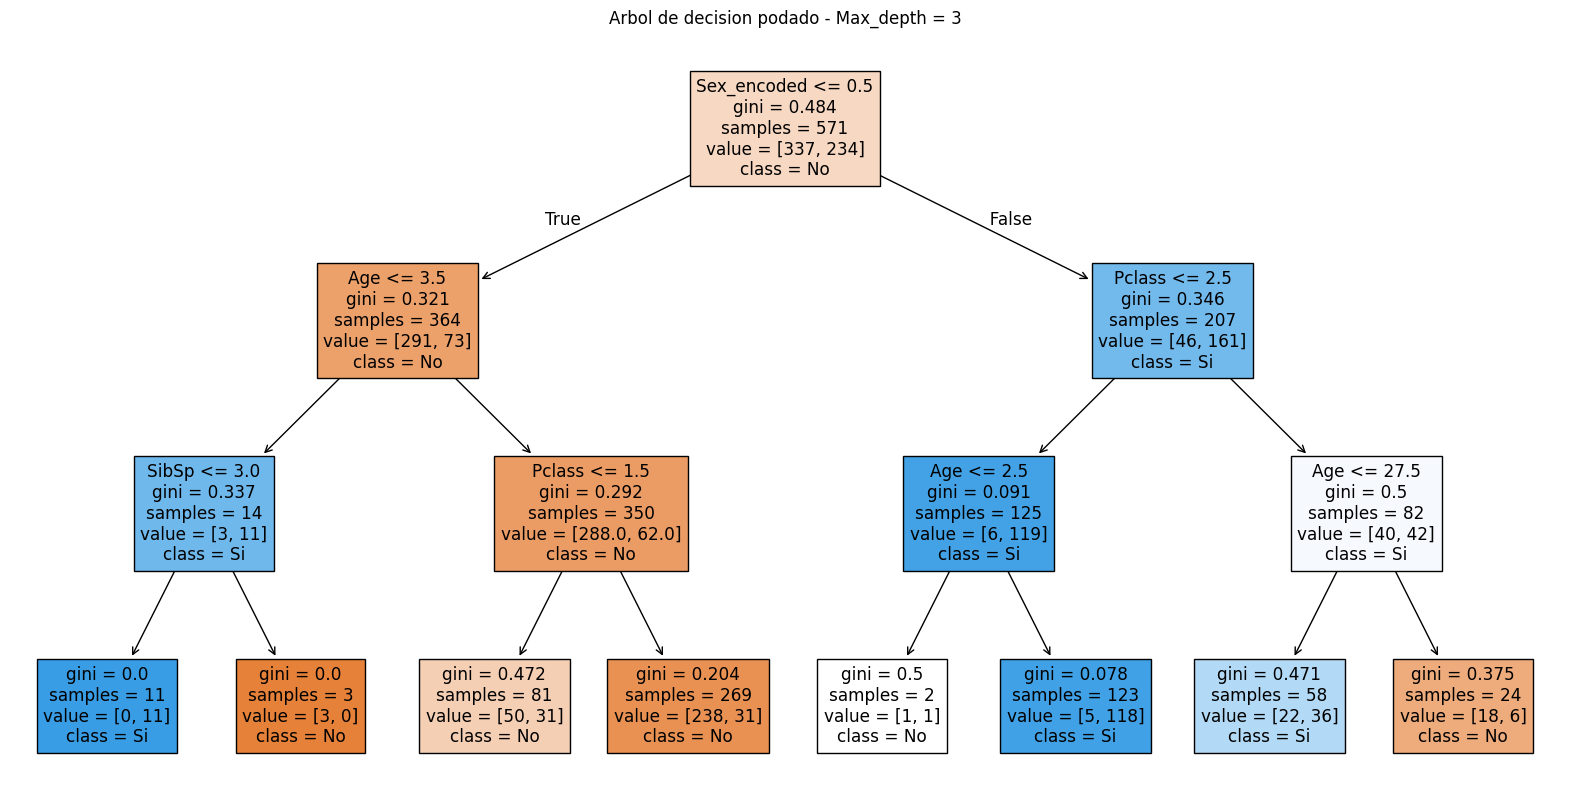

In [23]:
# Caso de setear profundidad maxima de 3, lim,itado al 3er nodo interno
# 01. Se setea el modelo
arbol_podado = DecisionTreeClassifier(random_state = 42, max_depth = 3)
# 02. Se entrena
arbol_podado.fit (x_train, y_train)
# Evaluacion del desempeño
# 01. Predicciones del arbol sobre el conjunto de prueba
y_pred_podado= arbol_podado.predict (x_test)

# 02. Reporte de clasificación
# \ ALT 92
print("Reporte de clasificacion - Árbol podado:\n")
print(classification_report(y_test, y_pred_podado))

# 03. Matriz de confusion
print("Matriz de confusión:")
print(confusion_matrix (y_test, y_pred_podado))


# 04. Visualizamos el arbol
plt.figure (figsize = (20,10))
plot_tree(arbol_podado, feature_names = X.columns, class_names = ["No", "Si"], filled = True)
plt.title("Arbol de decision podado - Max_depth = 3")
plt.show()

Reporte de clasificacion - Árbol podado:

              precision    recall  f1-score   support

         0.0       0.77      0.83      0.80        87
         1.0       0.69      0.61      0.65        56

    accuracy                           0.74       143
   macro avg       0.73      0.72      0.72       143
weighted avg       0.74      0.74      0.74       143

Matriz de confusión:
[[72 15]
 [22 34]]


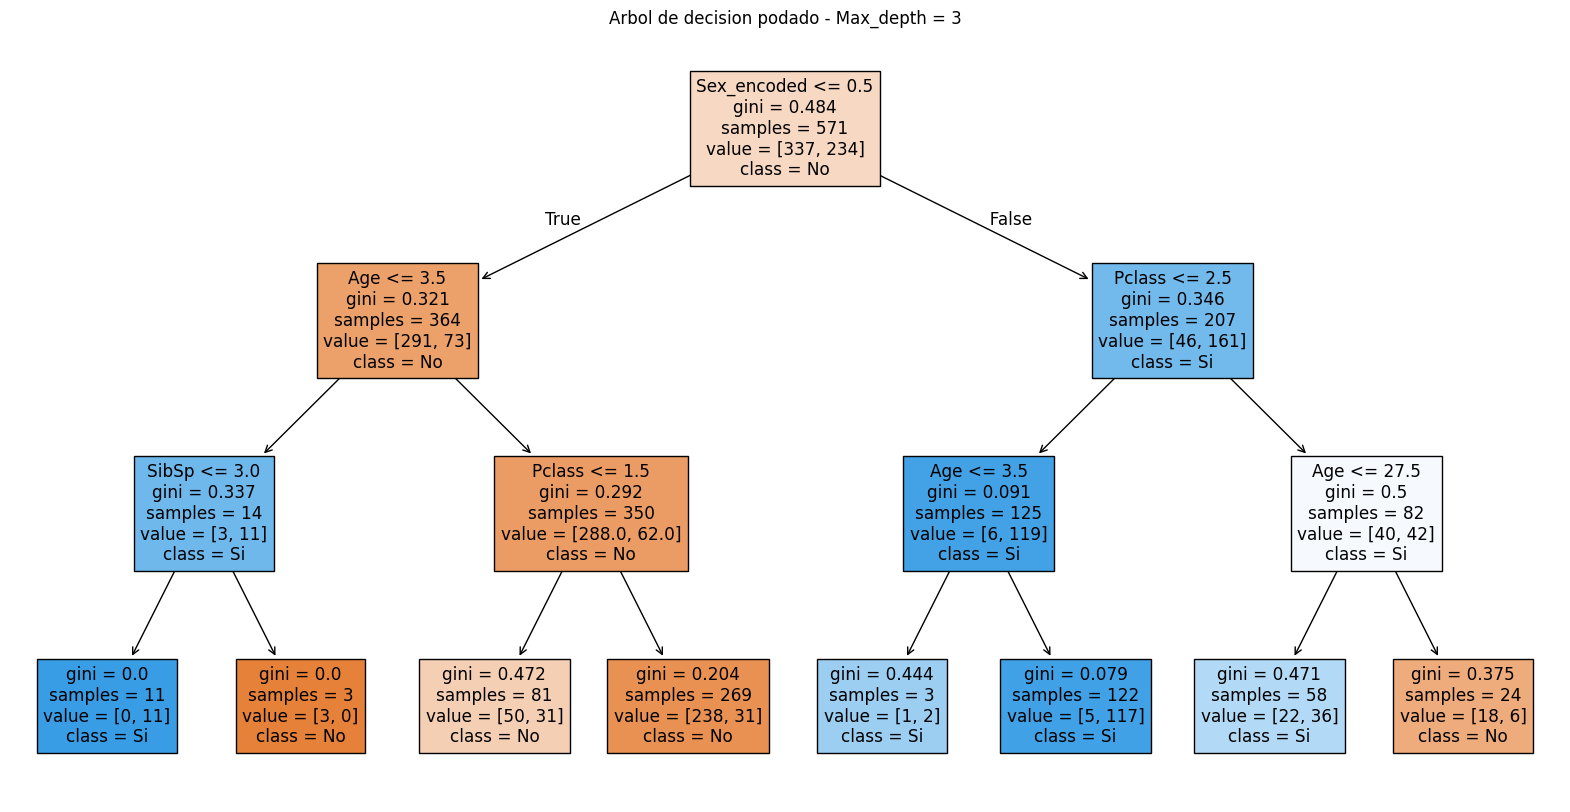

In [ ]:
# Otro caso de setear  le decis al algoritmo que minimo para crear una nueva hoja tiene que haber 3 datos (3 personas)
# Lo ideal es empezar probando con 4-5 leaf (hojas)
arbol_podado_minLeaf = DecisionTreeClassifier(random_state = 42, max_depth = 3, min_samples_leaf = 3)
# 02. Se entrena
arbol_podado_minLeaf.fit (x_train, y_train)
# Evaluacion del desempeño
# 01. Predicciones del arbol sobre el conjunto de prueba
y_pred_podado_minLeaf= arbol_podado_minLeaf.predict (x_test)

# 02. Reporte de clasificación
# \ ALT 92
print("Reporte de clasificacion - Árbol podado:\n")
print(classification_report(y_test, y_pred_podado_minLeaf))

# 03. Matriz de confusion
print("Matriz de confusión:")
print(confusion_matrix (y_test, y_pred_podado_minLeaf))


# 04. Visualizamos el arbol
plt.figure (figsize = (20,10))
plot_tree(arbol_podado_minLeaf, feature_names = X.columns, class_names = ["No", "Si"], filled = True)
plt.title("Arbol de decision podado - Max_depth = 3")
plt.show()

In [ ]:
# Ejemplo para probar de forma iterativa cual seria el mejor min_sample_leaf

# DataFrame donde se almacenarán los resultados
resultados = []

# Probar distintos valores de min_samples_leaf
for hoja in range(2, 8):

    # Crear el árbol
    arbol = DecisionTreeClassifier( random_state=42, max_depth=3, min_samples_leaf=hoja )

    # Entrenar el modelo
    arbol.fit(x_train, y_train)

    # Predicciones
    y_pred = arbol.predict(x_test)

    # Guardar métricas
    resultados.append({
        "min_samples_leaf": hoja,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

# Convertir a DataFrame
resultados = pd.DataFrame(resultados)

# Ordenar por accuracy (opcional)
resultados = resultados.sort_values("Accuracy", ascending=False)

print(resultados)

   min_samples_leaf  Accuracy  Precision    Recall  F1-score
3                 5  0.748252   0.708333  0.607143  0.653846
2                 4  0.748252   0.708333  0.607143  0.653846
4                 6  0.748252   0.708333  0.607143  0.653846
0                 2  0.741259   0.693878  0.607143  0.647619
1                 3  0.741259   0.693878  0.607143  0.647619
5                 7  0.741259   0.686275  0.625000  0.654206


In [28]:
# Ejemplo para probar de forma iterativa cual seria el mejor max_depth

# DataFrame donde se almacenarán los resultados
resultados_profundidad = []

# Probar distintos valores de min_samples_leaf
for profundidad in range(1, 11):

    # Crear el árbol
    arbol = DecisionTreeClassifier( random_state = 42, max_depth = profundidad, min_samples_leaf = 4)

    # Entrenar el modelo
    arbol.fit(x_train, y_train)

    # Predicciones
    y_pred = arbol.predict(x_test)

    # Guardar métricas
    resultados_profundidad.append({
        "Profunidad": profundidad,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

# Convertir a DataFrame
resultados_profundidad = pd.DataFrame(resultados_profundidad)

# Ordenar por accuracy (opcional)
resultados_profundidad = resultados_profundidad.sort_values("Accuracy", ascending=False)

print(resultados_profundidad)

   Profunidad  Accuracy  Precision    Recall  F1-score
9          10  0.790210   0.750000  0.696429  0.722222
8           9  0.790210   0.750000  0.696429  0.722222
7           8  0.790210   0.750000  0.696429  0.722222
5           6  0.769231   0.716981  0.678571  0.697248
6           7  0.762238   0.703704  0.678571  0.690909
3           4  0.755245   0.684211  0.696429  0.690265
4           5  0.748252   0.678571  0.678571  0.678571
2           3  0.748252   0.708333  0.607143  0.653846
1           2  0.734266   0.655172  0.678571  0.666667
0           1  0.734266   0.666667  0.642857  0.654545


In [29]:
# Pruebo las dos cosas al mismo tiempo para encontrar la mejor combinación


# Lista para guardar resultados
resultados = []

# Probar todas las combinaciones
for profundidad in range(2, 11):

    for hoja in range(2, 8):

        # Crear árbol
        arbol = DecisionTreeClassifier(random_state = 42, max_depth = profundidad, min_samples_leaf = hoja)

        # Entrenar
        arbol.fit(x_train, y_train)

        # Predicciones
        y_pred = arbol.predict(x_test)

        # Guardar métricas
        resultados.append({
            "max_depth": profundidad,
            "min_samples_leaf": hoja,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-score": f1_score(y_test, y_pred)
        })

# Convertir a DataFrame
resultados = pd.DataFrame(resultados)

# Ordenar por Accuracy y luego F1-score
resultados = resultados.sort_values(by = ["Accuracy", "F1-score"], ascending = False)

print(resultados)

    max_depth  min_samples_leaf  Accuracy  Precision    Recall  F1-score
39          8                 5  0.797203   0.764706  0.696429  0.728972
45          9                 5  0.797203   0.764706  0.696429  0.728972
51         10                 5  0.797203   0.764706  0.696429  0.728972
37          8                 3  0.790210   0.732143  0.732143  0.732143
43          9                 3  0.790210   0.732143  0.732143  0.732143
49         10                 3  0.790210   0.732143  0.732143  0.732143
38          8                 4  0.790210   0.750000  0.696429  0.722222
44          9                 4  0.790210   0.750000  0.696429  0.722222
50         10                 4  0.790210   0.750000  0.696429  0.722222
42          9                 2  0.783217   0.727273  0.714286  0.720721
48         10                 2  0.783217   0.735849  0.696429  0.715596
40          8                 6  0.783217   0.755102  0.660714  0.704762
46          9                 6  0.783217   0.75510

In [30]:
# Seleccionamos cual es el mejor modelo, que seria el primero porque lo ordenamos
mejor_modelo = resultados.iloc[0]

print(f"Mejor max_depth: {mejor_modelo['max_depth']}")
print(f"Mejor min_samples_leaf: {mejor_modelo['min_samples_leaf']}")
print(f"Accuracy: {mejor_modelo['Accuracy']:.3f}")

Mejor max_depth: 8.0
Mejor min_samples_leaf: 5.0
Accuracy: 0.797


Este proceso se automatiza con la herramienta GridSearchCV pero seria ya con validación cruzada